In [18]:
import sys
import optuna
import pandas as pd
from dotenv import load_dotenv
from strategies_utils import analyze_strategies, get_best_leagues

In [19]:
import os
os.chdir("../models/")
from feature_engineering import get_mask, round_to_step, get_return, add_week_column
from etl_pipeline_local import get_over_15_table, get_win_1x_table, get_btts_table
os.chdir("../strategies/")
load_dotenv()

True

In [20]:
strategy_dict = dict()

# 1. Over 1.5

In [21]:
target_col = "over_15"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 3
Best assoluto: -0.13275429337616318 {'underOver_quote_diffRealCurrU_use_min': False, 'underOver_quote_diffRealCurrU_use_max': True, 'use_underOver_quote_diffRealCurrU': False, 'underOver_quote_diffRealCurrU_min': 85, 'underOver_quote_diffRealCurrU_max': 300, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': False, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.4000000000000001, 'goalNoGoal_stats_avgGoalTakenAway_max': 4.2, 'goalNoGoal_flashback_m24_include_missing': False, 'goalNoGoal_flashback_m24_use_min': True, 'goalNoGoal_flashback_m24_use_max': True, 'use_goalNoGoal_flashback_m24': True, 'goalNoGoal_flashback_m24_min': 62, 'goalNoGoal_flashback_m24_max': 63, 'underOver_chance_over25_use_min': False, 'underOver_chance_over25_use_max': True, 'use_underOver_chance_over25': True, 'underOver_chance_over25_min': 25, 'underOver_chance_over25_max': 60, 'underOver_comparison_aff

/tmp/ipykernel_61321/141665692.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.2] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_61321/141665692.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  print("Totale trial salvati:", len(study.trials))


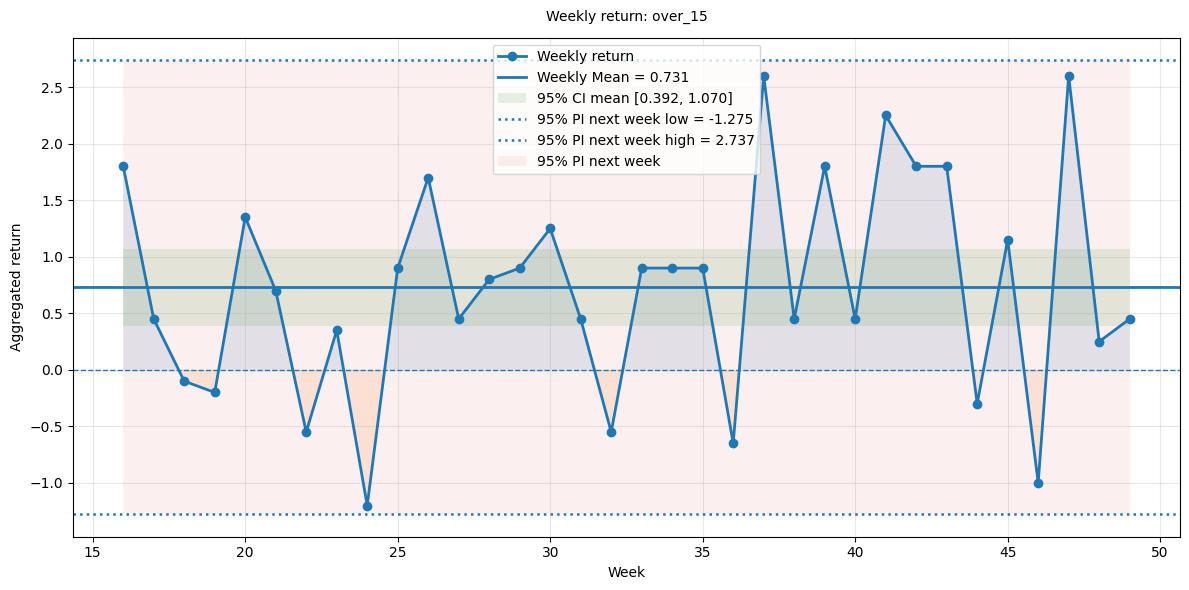

In [22]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]
# Bet setup
target_col = "over_15"
odds_col: str = "over_15_odds"

# Load data
df_loaded = get_over_15_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df[odds_col] = 1.45
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[df["underOver_quote_currentU"] <= 1.7]
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]

strategy_dict[target_col] = {"df_filtered": df_filtered, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}
weekly_return, stats = analyze_strategies(df_filtered[['return', 'week', 'strategy']], strategies=[target_col], print_pi=True)

# 2. DNB 1

In [23]:
target_col = "dnb_1"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.4140076147684093 {'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'use_underOver_comparison_affini': False, 'underOver_comparison_affini_min': 500, 'underOver_comparison_affini_max': 1000, 'underOver_quote_diffRealCurrO_use_min': False, 'underOver_quote_diffRealCurrO_use_max': True, 'use_underOver_quote_diffRealCurrO': True, 'underOver_quote_diffRealCurrO_min': 55, 'underOver_quote_diffRealCurrO_max': 190, 'underOver_quote_realU_use_min': True, 'underOver_quote_realU_use_max': True, 'use_underOver_quote_realU': False, 'underOver_quote_realU_min': 2.0, 'underOver_quote_realU_max': 5.800000000000001, 'evaluation_valUnderOver_cat_idx': 47, 'use_evaluation_valUnderOver': True, 'underOver_quote_diffInitialCurrO_use_min': False, 'underOver_quote_diffInitialCurrO_use_max': True, 'use_underOver_quote_diffInitialCurrO': True, 'underOver_quote_diffInitialCurrO_min': -15, 'underOver_quote_diffInitialCurrO_max': 5

/tmp/ipykernel_61321/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.2] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_61321/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_61321/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 3.8000000000000003] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 3.8000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_61321/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 4.0] and step=0.2, but th

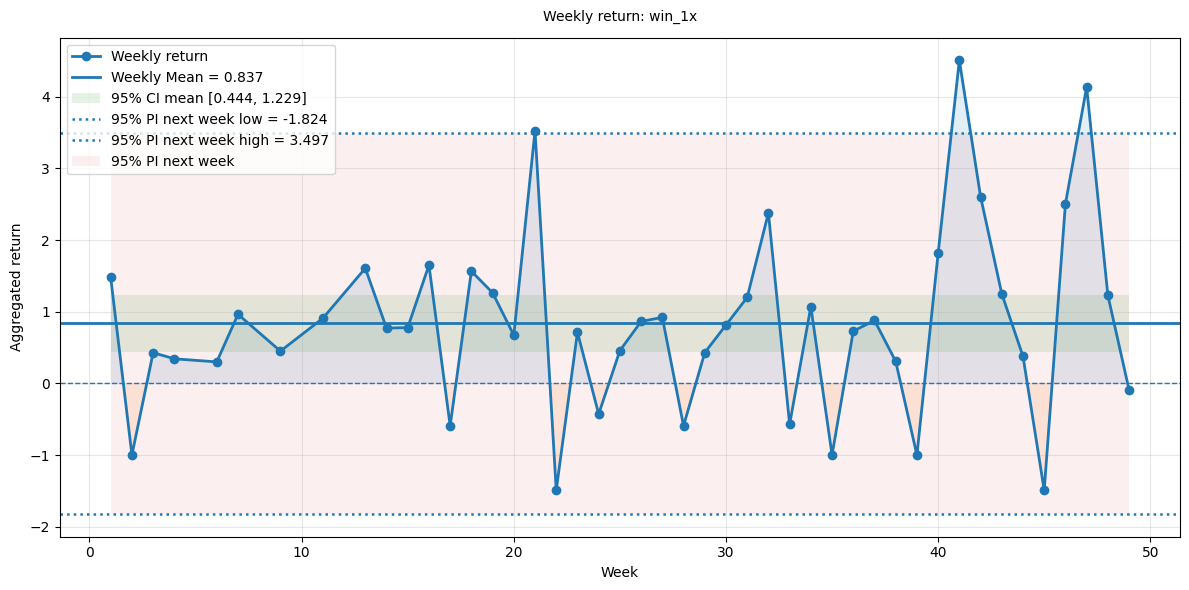

In [24]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_1x"
odds_col: str = "dnb_1_odds"

# Load data
df_loaded = get_win_1x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
def scale_odd(quota_orig):
    return (3/7) * quota_orig + 0.4857142857

# Feature Engineering
df[odds_col] = [scale_odd(x) for x in df['chance1x2_quote_current1']]


df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df["chance1x2_quote_current1"] >= 1.9) & (df["chance1x2_quote_current1"] <= 2.6)]

df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "weekly_return": weekly_return, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

# 3. BTTS

In [25]:
target_col = "btts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.28668743594845136 {'goalNoGoal_quote_diffRealCurrNG_use_min': False, 'goalNoGoal_quote_diffRealCurrNG_use_max': True, 'use_goalNoGoal_quote_diffRealCurrNG': False, 'goalNoGoal_quote_diffRealCurrNG_min': -45, 'goalNoGoal_quote_diffRealCurrNG_max': 125, 'underOver_chance_over45_use_min': True, 'underOver_chance_over45_use_max': True, 'use_underOver_chance_over45': True, 'underOver_chance_over45_min': 35, 'underOver_chance_over45_max': 55, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': True, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.8, 'goalNoGoal_stats_avgGoalTakenAway_max': 3.2, 'underOver_quote_initialU_use_min': True, 'underOver_quote_initialU_use_max': False, 'use_underOver_quote_initialU': True, 'underOver_quote_initialU_min': 2.0, 'underOver_quote_initialU_max': 3.6000000000000005}


/tmp/ipykernel_61321/4038310933.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 4.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 4.6000000000000005].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_61321/4038310933.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 4.8] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 4.6000000000000005].
  print("Totale trial salvati:", len(study.trials))


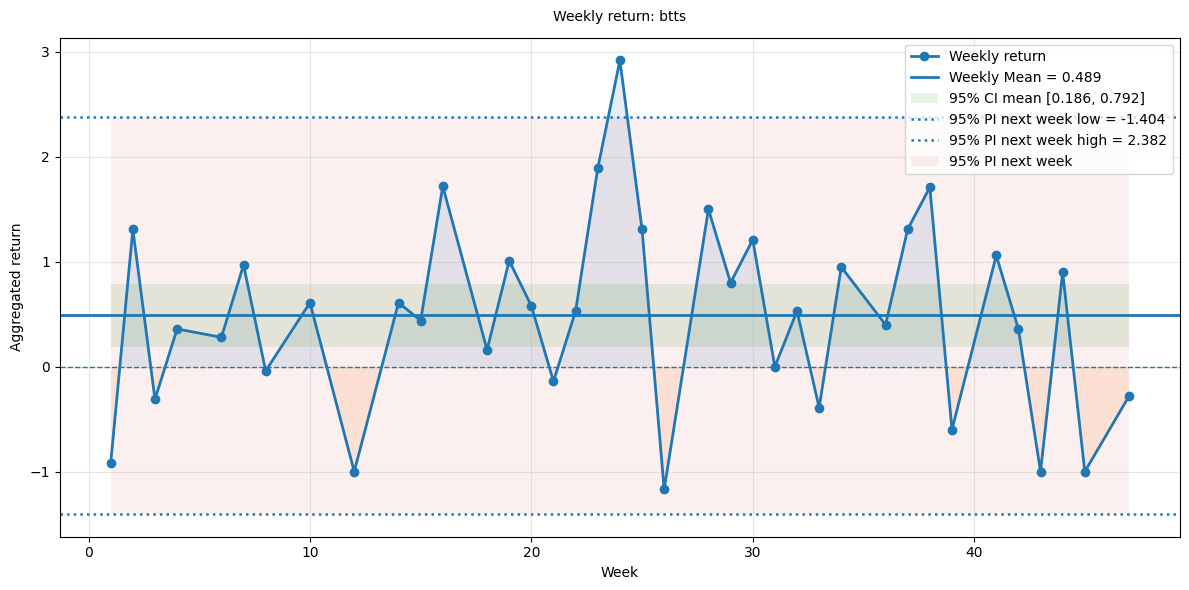

In [26]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"

# Load data
df_loaded = get_btts_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "weekly_return": weekly_return, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

# Forecast

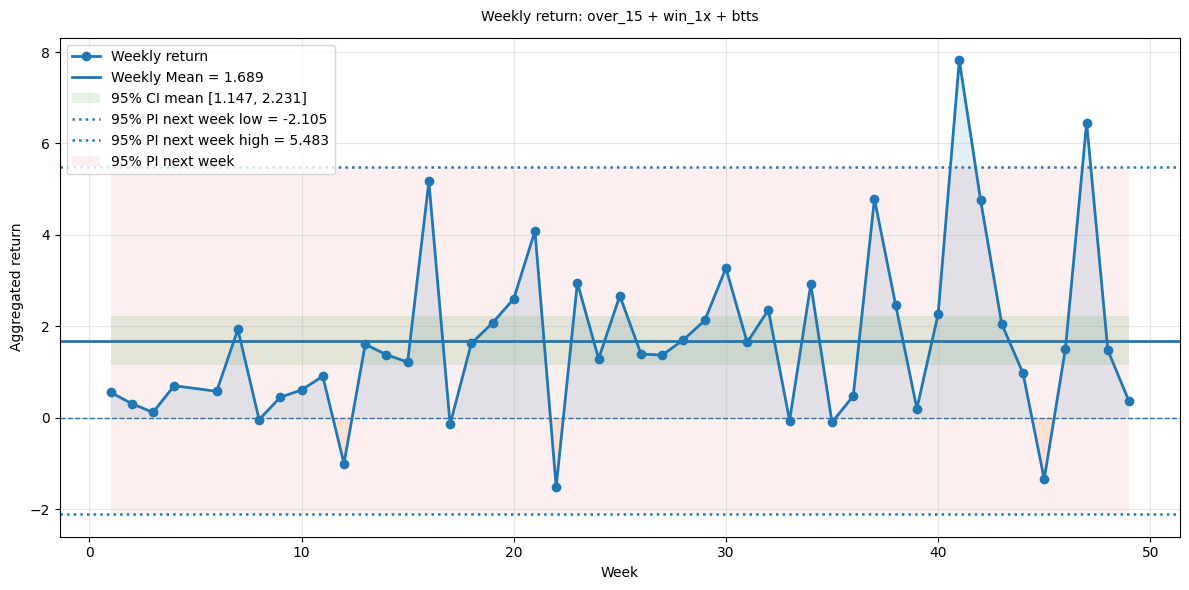

In [27]:
for i, key in enumerate(strategy_dict.keys()):
    if i == 0:
        df_final = strategy_dict[key]['df_filtered']
    else:
        df_item = strategy_dict[key]['df_filtered']
        df_final = pd.concat([df_final, df_item], axis=0)

df_final = df_final.reset_index(drop=True)

weekly_return, stats = analyze_strategies(df_final, strategies=strategy_dict.keys(), print_pi=True)

In [28]:
df_final = df_final.rename(columns={"team_league": "league"})

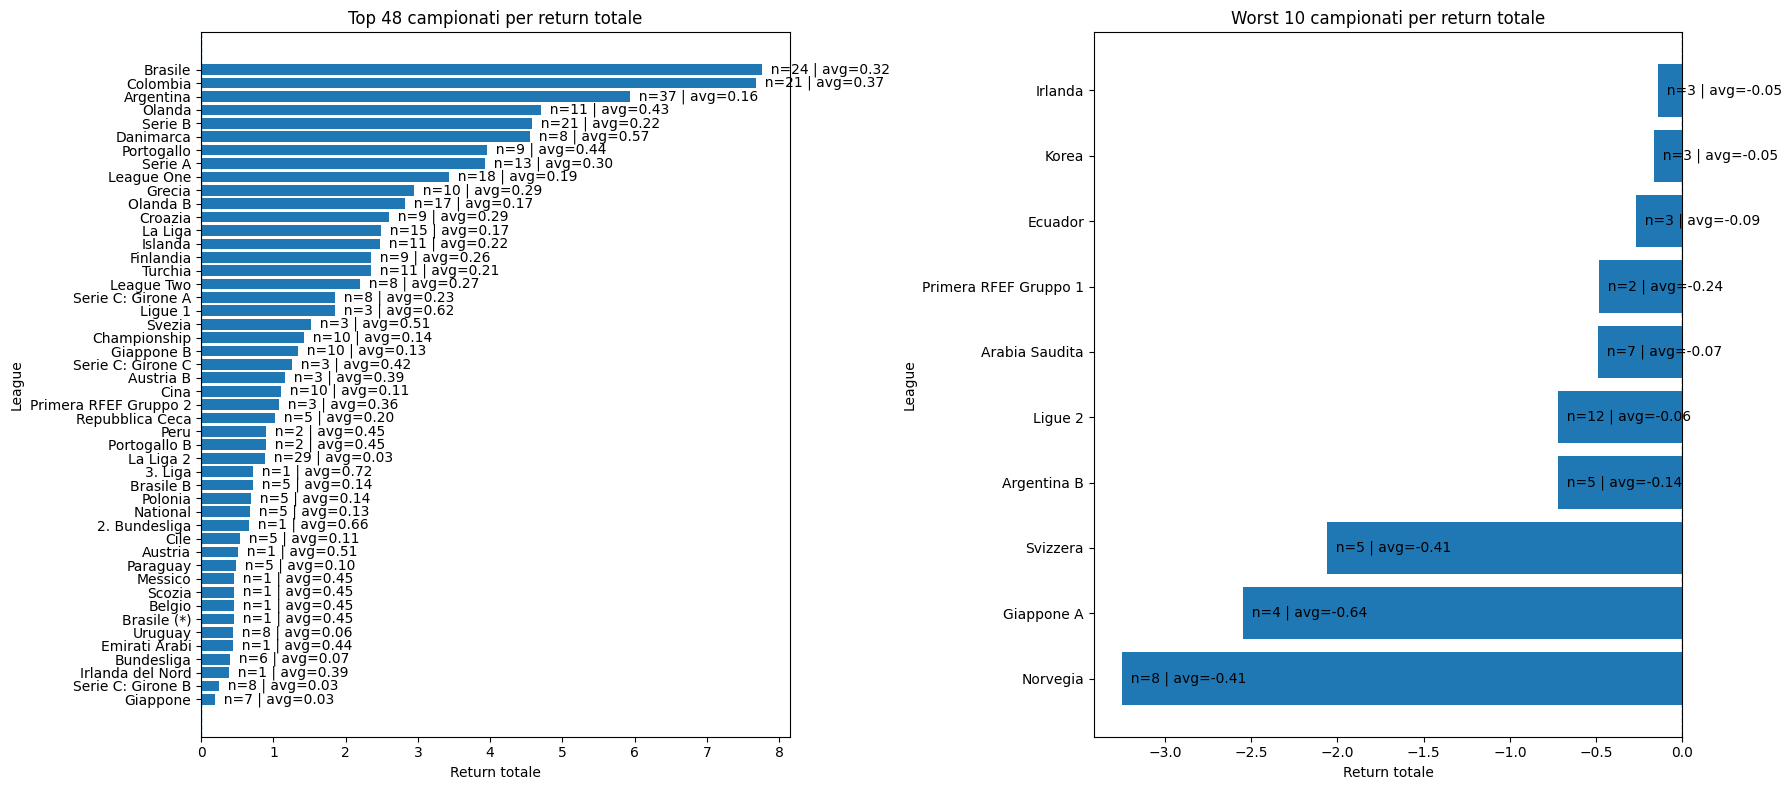

In [29]:
top_leagues = get_best_leagues(df_final, strategies=strategy_dict.keys())

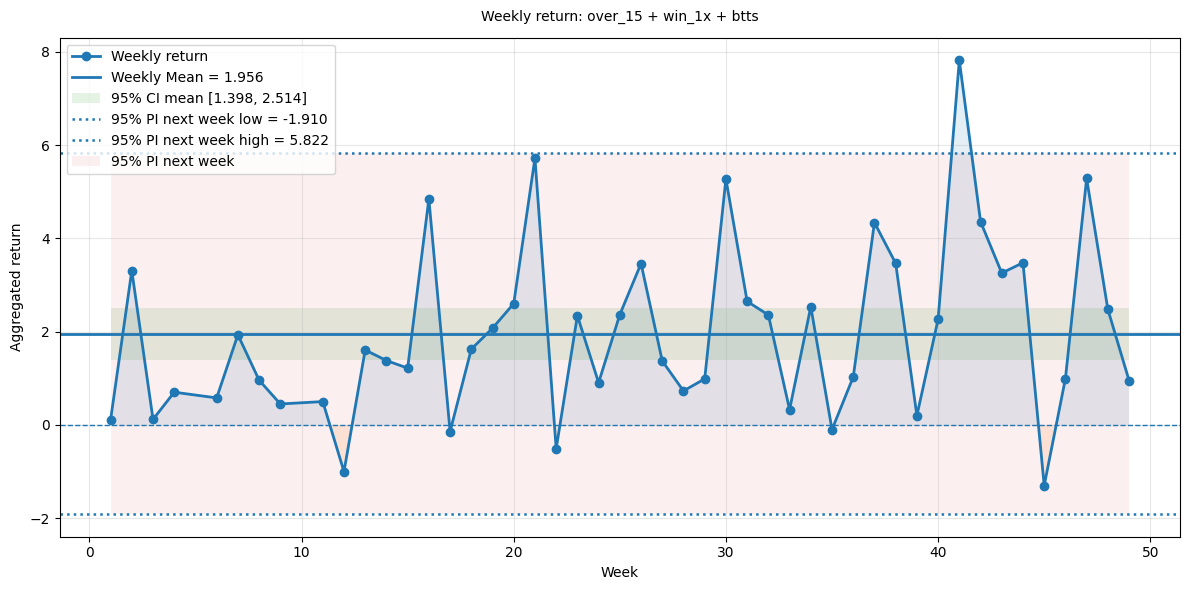

In [30]:
weekly_return, stats = analyze_strategies(df_final, strategies=strategy_dict.keys(), leagues=top_leagues.index.to_list(),print_pi=True)

In [31]:
output_dict = dict()

output_dict["over_15"]= strategy_dict["over_15"]['settings']
output_dict["dnb_1"]= strategy_dict["win_1x"]['settings']
output_dict["btts"]= strategy_dict["btts"]['settings']

In [32]:
import json 
with open("strategies.json", "w", encoding="utf-8") as f:
    json.dump(output_dict, f, indent=2)